# P&L — Did the Strategy Actually Make Money?

This is the last stage of the pipeline and the one that produces the answer.

```
semiconductor_data.csv --> signal.ipynb --> signal_picks.csv --> execution.ipynb --> execution_fills.csv --> THIS NOTEBOOK
```

**What the earlier notebooks do, in one line each:**
- **Data** downloads two years of daily prices for 20 semiconductor stocks.
- **Signal** picks the 5 strongest and 5 weakest names each week (long the strong, short the weak).
- **Execution** estimates what price we would really have paid to get into each of those positions.

**What this notebook does:** it takes every one of those positions, holds it for one week,
closes it, and adds up the money made or lost. Then it turns 100 weeks of results into
the numbers a portfolio manager would ask for: total return, risk, Sharpe ratio, worst
losing streak, and how much execution costs ate into the result.

**Plain-English glossary for the terms below:**
- **Position** — one bet on one stock for one week. Long = we own it and want it to go up.
  Short = we borrowed and sold it, and want it to go down.
- **Entry / exit price** — what we paid to get in, and what we got when we got out.
- **Gross** — profit before any trading costs. **Net** — profit after trading costs.
- **Equity curve** — a line showing how much money the portfolio has over time.
- **Drawdown** — how far the equity curve has fallen from its previous high point.
  The max drawdown is the worst peak-to-trough loss you would have lived through.
- **Sharpe ratio** — return divided by risk. Roughly: how much reward per unit of
  bumpiness. Above 1 is good for a strategy like this, below 0.5 is weak.
- **Hit rate** — the fraction of weeks that made money.
- **bps** — basis points. 1 bp = 0.01%, so 100 bps = 1%.

**Outputs:**
- `pnl_positions.csv` — one row per position with its dollar P&L.
- `pnl_weekly.csv` — one row per week with the portfolio return.
- `pnl_summary.csv` — the headline statistics table.
- `pnl_equity_curve.png` — the chart.


## Step 0 — Settings

Everything the team might want to change lives here, in one place.

- `CAPITAL_BASE` is how much money the portfolio starts with. It **must match** the
  same number in `execution.ipynb`, because that notebook already decided how many
  shares to buy using it. The actual dollar amount is arbitrary for a backtest (returns
  are in percent), but it makes the dollar P&L readable.
- `COMPOUND` controls whether profits are reinvested. `True` means a good week makes
  next week's positions slightly bigger, which is how a real fund behaves. `False`
  keeps every week at exactly the starting capital, which is simpler to reason about.
- `BORROW_COST_ANNUAL` is the fee a broker charges to lend you shares for a short.
  It is set to zero for now so the result is clean. Flip it to something like `0.005`
  (0.5% a year) later to see how much it matters.


In [1]:
# ============================================================
# CONFIG
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_CSV   = "semiconductor_data.csv"
FILLS_CSV  = "execution_fills.csv"

OUT_POSITIONS = "pnl_positions.csv"
OUT_WEEKLY    = "pnl_weekly.csv"
OUT_SUMMARY   = "pnl_summary.csv"
OUT_CHART     = "pnl_equity_curve.png"

CAPITAL_BASE = 10_000_000     # starting portfolio value ($). MUST match execution.ipynb.
N_LONG  = 5                   # picks per side, from signal.ipynb
N_SHORT = 5
N_LEGS  = N_LONG + N_SHORT

COMPOUND = True               # reinvest profits week to week?
BORROW_COST_ANNUAL = 0.0      # yearly fee for borrowing shares to short (0 = ignore for now)
WEEKS_PER_YEAR = 52           # used to annualise weekly numbers

# The three "versions" of every position we will track. Each one uses a different
# entry price. Gross = the ideal price, the other two = what Execution says we'd really pay.
STRATEGIES = {
    "gross":     "arrival_price",     # entry at the week's open, zero cost -- the ideal case
    "allatonce": "fill_allatonce",    # whole order sent at the open, pays full market impact
    "twap":      "fill_twap",         # order spread over the week's daily opens
}

print(f"Capital: ${CAPITAL_BASE:,.0f} | {N_LEGS} positions per week | compounding: {COMPOUND}")


Capital: $10,000,000 | 10 positions per week | compounding: True


## Step 1 — Load the inputs and check they look right

We read two files: the daily prices (to find out where each stock ended the week) and
the execution fills (what we paid to get in, for each position).

The `assert` lines are guard rails. If someone changes an upstream notebook and a column
disappears, we want this cell to stop immediately with a clear message, not silently
produce wrong numbers five cells later.

We also check that every week has exactly 10 positions. Signal promised 5 longs and
5 shorts per week, and Execution only drops a pick if it has no price data. If a week
shows up with 9 or 11 rows, something upstream is broken.


In [2]:
# ============================================================
# 1. LOAD + VALIDATE
# ============================================================
prices = pd.read_csv(DATA_CSV, parse_dates=["date"]).sort_values(["ticker", "date"]).reset_index(drop=True)
fills  = pd.read_csv(FILLS_CSV)

need_prices = {"date", "ticker", "open", "close", "week_number"}
need_fills  = {"week_number", "ticker", "side", "shares", "arrival_price", "fill_allatonce", "fill_twap"}
assert need_prices <= set(prices.columns), f"prices missing columns: {need_prices - set(prices.columns)}"
assert need_fills  <= set(fills.columns),  f"fills missing columns: {need_fills - set(fills.columns)}"

legs_per_week = fills.groupby("week_number").size()
bad_weeks = legs_per_week[legs_per_week != N_LEGS]
assert len(bad_weeks) == 0, f"These weeks don't have exactly {N_LEGS} positions: {dict(bad_weeks)}"

print(f"Prices: {len(prices):,} rows, {prices['ticker'].nunique()} tickers, weeks {prices['week_number'].min()}-{prices['week_number'].max()}")
print(f"Fills:  {len(fills):,} positions across {fills['week_number'].nunique()} traded weeks "
      f"(weeks {fills['week_number'].min()}-{fills['week_number'].max()})")
print(f"Every traded week has exactly {N_LEGS} positions. OK.")


Prices: 10,040 rows, 20 tickers, weeks 1-105
Fills:  1,000 positions across 100 traded weeks (weeks 6-105)
Every traded week has exactly 10 positions. OK.


## Step 2 — Find the exit price for every position

The holding rule is simple: **every position opens at the week's first open and closes
at the week's last close.** Nothing is carried over the weekend. That keeps each week
independent, so we never have to track a stock that was long one week and short the next.

The entry price is already in the fills file. The exit price is not, so we build it here:
for each stock and each week, take the close on the last trading day of that week.
A short week (holiday on Friday) still works, because "last trading day" is whatever
day it happens to be.

Then we attach that exit price to every position by matching on week and ticker.


In [3]:
# ============================================================
# 2. EXIT PRICE = close on the last trading day of the week
# ============================================================
last_day = (
    prices.sort_values("date")
          .groupby(["ticker", "week_number"])
          .tail(1)[["ticker", "week_number", "date", "close"]]
          .rename(columns={"date": "exit_date", "close": "exit_price"})
)

positions = fills.merge(last_day, on=["ticker", "week_number"], how="left")

missing_exit = positions["exit_price"].isna().sum()
assert missing_exit == 0, f"{missing_exit} positions have no exit price -- check the price data"

print(f"Exit prices attached to all {len(positions):,} positions.")
print(positions[["week_number", "ticker", "side", "shares", "arrival_price", "exit_date", "exit_price"]].head(10).to_string(index=False))


Exit prices attached to all 1,000 positions.
 week_number ticker  side  shares  arrival_price  exit_date  exit_price
           6   AVGO  long    5808     172.157265 2024-10-11  178.715836
           6    AMD  long    5845     171.080002 2024-10-11  167.889999
           6   NVDA  long    8013     124.795000 2024-10-11  134.589722
           6   INTC  long   44642      22.400000 2024-10-11   23.559999
           6     MU  long    9839     101.635822 2024-10-11  106.371407
           6   SWKS short   11185      89.401783 2024-10-11   90.744766
           6    STM short   36466      27.422301 2024-10-11   27.363541
           6    TXN short    5268     189.818559 2024-10-11  194.095840
           6   NXPI short    4355     229.580613 2024-10-11  230.665665
           6   MCHP short   13749      72.731959 2024-10-11   73.820625


## Step 3 — Position accounting: how much did each position make or lose?

This is the heart of the notebook. For every position we compute the dollar profit or loss.

The formula is the same for every position:

```
dollar P&L  =  direction  x  shares  x  (exit price - entry price)
```

- `direction` is **+1 for a long** and **-1 for a short**. For a long, a rising price is a
  gain. For a short, a rising price is a loss, and the -1 flips the sign so the formula
  still gives the right answer.
- `shares` came from Execution: it is the dollar allocation divided by the arrival price,
  rounded down.
- `entry price` is where the three versions differ. We compute P&L three times with
  three different entries: the ideal arrival price (gross), the all-at-once fill, and
  the TWAP fill. Same shares, same exit, just a different starting price.

We also compute each position's **return** (P&L divided by the dollars we put in) and
the **execution cost in dollars** (gross P&L minus net P&L). That cost number is what
market impact actually cost us, in money rather than basis points.

If a borrow cost is set, shorts pay one week's worth of it on the dollars they borrowed.


In [4]:
# ============================================================
# 3. POSITION ACCOUNTING
# ============================================================
positions["direction"] = np.where(positions["side"] == "long", 1, -1)

# Dollars actually put into this position (shares x arrival price). Because shares were
# rounded down, this is slightly less than the $ allocation -- the difference sits in cash.
positions["notional"] = positions["shares"] * positions["arrival_price"]

# One week of borrow fee, charged only on shorts
weekly_borrow_rate = BORROW_COST_ANNUAL / WEEKS_PER_YEAR
positions["borrow_cost"] = np.where(positions["side"] == "short",
                                    positions["notional"] * weekly_borrow_rate, 0.0)

# P&L and return for each of the three entry-price versions
for name, entry_col in STRATEGIES.items():
    pnl = positions["direction"] * positions["shares"] * (positions["exit_price"] - positions[entry_col])
    pnl = pnl - positions["borrow_cost"]
    positions[f"pnl_{name}"] = pnl
    positions[f"ret_{name}"] = pnl / positions["notional"]

# What did trading cost us, in dollars? Gross is the no-cost ideal, so gross - net = cost.
positions["exec_cost_allatonce"] = positions["pnl_gross"] - positions["pnl_allatonce"]
positions["exec_cost_twap"]      = positions["pnl_gross"] - positions["pnl_twap"]

print("Per-position P&L computed. First week, long side:")
show = ["week_number", "ticker", "side", "shares", "arrival_price", "exit_price",
        "pnl_gross", "pnl_allatonce", "pnl_twap", "exec_cost_allatonce", "exec_cost_twap"]
print(positions[positions["side"] == "long"][show].head(5).round(2).to_string(index=False))
print()
print(f"Total gross P&L over all positions:        ${positions['pnl_gross'].sum():>14,.0f}")
print(f"Total execution cost, all-at-once:         ${positions['exec_cost_allatonce'].sum():>14,.0f}")
print(f"Total execution cost, TWAP:                ${positions['exec_cost_twap'].sum():>14,.0f}")


Per-position P&L computed. First week, long side:
 week_number ticker side  shares  arrival_price  exit_price  pnl_gross  pnl_allatonce  pnl_twap  exec_cost_allatonce  exec_cost_twap
           6   AVGO long    5808         172.16      178.72   38092.18       37725.87  14954.93               366.31        23137.25
           6    AMD long    5845         171.08      167.89  -18645.56      -18963.95 -13444.85               318.39        -5200.71
           6   NVDA long    8013         124.80      134.59   78485.10       78339.38  29885.63               145.73        48599.47
           6   INTC long   44642          22.40       23.56   51784.71       51263.02  32440.16               521.70        19344.56
           6     MU long    9839         101.64      106.37   46593.42       45851.53  41953.20               741.89         4640.22

Total gross P&L over all positions:        $     2,638,339
Total execution cost, all-at-once:         $       898,110
Total execution cost, TWAP:      

## Step 4 — Tie-out check: do our dollar costs agree with Execution's bps costs?

Execution already reported each order's "implementation shortfall" in basis points.
We just computed the same thing in dollars from a different direction. If the two
notebooks agree, converting our dollar cost back to bps should land on Execution's number.

This is the single most useful check in the file: it proves the two notebooks are
talking about the same positions. If it fails, something is mismatched (wrong shares,
wrong sign, wrong capital base) and nothing downstream can be trusted.


In [5]:
# ============================================================
# 4. TIE-OUT VS. EXECUTION NOTEBOOK
# ============================================================
# Our cost in bps = (dollar cost / dollars invested) x 10,000.
# Execution's number = shortfall_*_bps. These should match to rounding.
for name in ["allatonce", "twap"]:
    ours   = positions[f"exec_cost_{name}"] / positions["notional"] * 10_000
    theirs = positions[f"shortfall_{name}_bps"]
    max_gap = (ours - theirs).abs().max()
    status = "OK" if max_gap < 0.01 else "FAIL"
    print(f"[{status}] {name:>9}: max difference between our cost and Execution's shortfall = {max_gap:.4f} bps")


[OK] allatonce: max difference between our cost and Execution's shortfall = 0.0000 bps
[OK]      twap: max difference between our cost and Execution's shortfall = 0.0000 bps


## Step 5 — Roll the positions up into one number per week

Ten positions a week is too granular to judge. We add them up.

- **Weekly dollar P&L** is the sum of the 10 positions' P&L. We also keep the long side
  and short side separately, so later we can see which half of the book is doing the work.
- **Weekly return** is that dollar P&L divided by the capital. If `COMPOUND` is on, the
  capital for each week is whatever the portfolio was worth at the end of the previous
  week, so profits grow the position sizes (and losses shrink them). If it is off, every
  week is measured against the fixed starting capital.

One subtlety worth knowing: because half the money is long and half is short, the
portfolio return is **half** the long-minus-short spread that `signal.ipynb` reports.
If Signal says the average spread is 0.53% a week, expect roughly 0.26% here. We check
this explicitly in the sanity cell near the end.


In [6]:
# ============================================================
# 5. WEEKLY PORTFOLIO P&L AND RETURNS
# ============================================================
is_long  = positions["side"] == "long"
pnl_cols = [f"pnl_{s}" for s in STRATEGIES]

weekly = positions.groupby("week_number").agg(
    exit_date=("exit_date", "max"),
    deployed=("notional", "sum"),
    **{c: (c, "sum") for c in pnl_cols},
    exec_cost_allatonce=("exec_cost_allatonce", "sum"),
    exec_cost_twap=("exec_cost_twap", "sum"),
).reset_index()

by_side = positions.groupby(["week_number", "side"])["pnl_gross"].sum().unstack("side")
weekly["pnl_gross_long"]  = weekly["week_number"].map(by_side["long"])
weekly["pnl_gross_short"] = weekly["week_number"].map(by_side["short"])
weekly = weekly.sort_values("week_number").reset_index(drop=True)

# Returns. With compounding, week t's return is measured against week t-1's ending equity.
# Position sizes in dollars were fixed by Execution at CAPITAL_BASE, so to compound we
# scale each week's P&L by (equity / CAPITAL_BASE) -- i.e. "we'd have sized up by that much".
for name in STRATEGIES:
    r = weekly[f"pnl_{name}"] / CAPITAL_BASE          # return on starting capital
    if COMPOUND:
        equity = CAPITAL_BASE * (1 + r).cumprod()      # scale positions with equity
    else:
        equity = CAPITAL_BASE + weekly[f"pnl_{name}"].cumsum()
    weekly[f"ret_{name}"] = r
    weekly[f"equity_{name}"] = equity

weekly["ret_gross_long"]  = weekly["pnl_gross_long"]  / CAPITAL_BASE
weekly["ret_gross_short"] = weekly["pnl_gross_short"] / CAPITAL_BASE

print(f"{len(weekly)} weeks of portfolio returns.")
print(weekly[["week_number", "exit_date", "pnl_gross", "pnl_allatonce", "pnl_twap",
              "ret_gross", "ret_allatonce", "ret_twap"]].head(8)
      .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print()
print(f"Average weekly return -- gross: {weekly['ret_gross'].mean():.3%} | "
      f"all-at-once: {weekly['ret_allatonce'].mean():.3%} | TWAP: {weekly['ret_twap'].mean():.3%}")


100 weeks of portfolio returns.
 week_number  exit_date     pnl_gross  pnl_allatonce     pnl_twap  ret_gross  ret_allatonce  ret_twap
           6 2024-10-11  141,205.1218   133,192.5865  29,901.1369     0.0141         0.0133    0.0030
           7 2024-10-18  -33,633.8179   -42,261.1191  52,783.3625    -0.0034        -0.0042    0.0053
           8 2024-10-25 -115,969.6565  -123,609.6080 -84,959.4961    -0.0116        -0.0124   -0.0085
           9 2024-11-01   -2,874.8049   -10,951.0869  10,728.0149    -0.0003        -0.0011    0.0011
          10 2024-11-08  243,648.5316   234,868.6864 171,241.1796     0.0244         0.0235    0.0171
          11 2024-11-15   46,321.5254    37,243.6464  57,336.6070     0.0046         0.0037    0.0057
          12 2024-11-22  -61,904.8238   -71,334.2833 -78,466.3164    -0.0062        -0.0071   -0.0078
          13 2024-11-29  -38,370.3443   -48,768.1667  16,597.6625    -0.0038        -0.0049    0.0017

Average weekly return -- gross: 0.264% | all-at-o

## Step 6 — Equity curve and drawdown

The equity curve is the running value of the portfolio, week by week. It was already
built in the previous cell; here we add **drawdown**.

Drawdown answers: "at this point in time, how far below my best-ever value am I?"
It is computed as the current equity divided by the highest equity seen so far, minus one.
It is zero whenever we are at a new high and negative otherwise. The lowest point it
ever reaches is the **max drawdown**, which is the number investors care about most
after return, because it is the worst pain they would have had to sit through.


In [7]:
# ============================================================
# 6. DRAWDOWN
# ============================================================
for name in STRATEGIES:
    eq = weekly[f"equity_{name}"]
    running_peak = eq.cummax()
    weekly[f"drawdown_{name}"] = eq / running_peak - 1

for name in STRATEGIES:
    print(f"{name:>9}: final equity ${weekly[f'equity_{name}'].iloc[-1]:>13,.0f} | "
          f"max drawdown {weekly[f'drawdown_{name}'].min():.2%}")


    gross: final equity $   12,816,508 | max drawdown -8.62%
allatonce: final equity $   11,715,617 | max drawdown -11.85%
     twap: final equity $   12,010,352 | max drawdown -6.71%


## Step 7 — Performance statistics

Now we boil 100 weeks into a handful of numbers, once for each of the three versions.

- **Total return** — where the equity ended relative to where it started.
- **Annualised return** — the total return rescaled to a one-year rate so it can be
  compared with other strategies or an index.
- **Annualised volatility** — how bumpy the weekly returns are, scaled to a year.
  Weekly standard deviation times the square root of 52.
- **Sharpe ratio** — annualised return divided by annualised volatility. The
  risk-adjusted score. (We ignore the risk-free rate, which is the normal shortcut for
  a long/short strategy that is roughly cash-neutral.)
- **Max drawdown** — from the previous step.
- **Hit rate** — fraction of weeks with a positive return.
- **Best / worst week** — the extremes, so the averages have context.
- **Execution drag** — average cost per week in bps of capital. This is how much the
  trading itself takes off the top.

The long-only and short-only rows at the bottom show which side of the book earned the
gross result. In a momentum strategy during a bull market, it is common for the longs to
make money and the shorts to lose it, and that is worth knowing.


In [8]:
# ============================================================
# 7. SUMMARY STATISTICS
# ============================================================
def perf_stats(r, equity, label):
    r = r.dropna()
    n_weeks = len(r)
    total_ret = equity.iloc[-1] / CAPITAL_BASE - 1
    years = n_weeks / WEEKS_PER_YEAR
    ann_ret = (1 + total_ret) ** (1 / years) - 1 if years > 0 else np.nan
    ann_vol = r.std() * np.sqrt(WEEKS_PER_YEAR)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = (equity / equity.cummax() - 1).min()
    return pd.Series({
        "weeks": n_weeks,
        "total_return": total_ret,
        "annualised_return": ann_ret,
        "annualised_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": dd,
        "hit_rate": (r > 0).mean(),
        "avg_week": r.mean(),
        "best_week": r.max(),
        "worst_week": r.min(),
    }, name=label)

rows = [perf_stats(weekly[f"ret_{s}"], weekly[f"equity_{s}"], s) for s in STRATEGIES]
summary = pd.DataFrame(rows)

# Execution drag: average weekly cost as bps of capital, and total $ over the backtest
summary["exec_drag_bps_per_week"] = [
    0.0,
    (weekly["exec_cost_allatonce"] / CAPITAL_BASE * 10_000).mean(),
    (weekly["exec_cost_twap"]      / CAPITAL_BASE * 10_000).mean(),
]
summary["total_exec_cost_usd"] = [0.0, weekly["exec_cost_allatonce"].sum(), weekly["exec_cost_twap"].sum()]

fmt = {
    "weeks": "{:.0f}",
    "total_return": "{:.2%}", "annualised_return": "{:.2%}", "annualised_vol": "{:.2%}",
    "sharpe": "{:.2f}", "max_drawdown": "{:.2%}", "hit_rate": "{:.0%}",
    "avg_week": "{:.3%}", "best_week": "{:.2%}", "worst_week": "{:.2%}",
    "exec_drag_bps_per_week": "{:.2f}", "total_exec_cost_usd": "${:,.0f}",
}
# Build a text-only copy of the table for display (stats as rows, strategies as columns)
pretty = pd.DataFrame(
    {strat: [fmt[stat].format(summary.loc[strat, stat]) for stat in summary.columns]
     for strat in summary.index},
    index=summary.columns,
)

print("=" * 70)
print("PERFORMANCE SUMMARY (gross = no costs; the other two = after execution costs)")
print("=" * 70)
print(pretty.to_string())

# Which side of the book made the money?
print()
print("GROSS CONTRIBUTION BY SIDE (avg weekly return on total capital)")
print(f"  longs : {weekly['ret_gross_long'].mean():+.3%} per week  "
      f"(total ${weekly['pnl_gross_long'].sum():,.0f})")
print(f"  shorts: {weekly['ret_gross_short'].mean():+.3%} per week  "
      f"(total ${weekly['pnl_gross_short'].sum():,.0f})")


PERFORMANCE SUMMARY (gross = no costs; the other two = after execution costs)
                         gross allatonce      twap
weeks                      100       100       100
total_return            28.17%    17.16%    20.10%
annualised_return       13.77%     8.58%     9.99%
annualised_vol          12.73%    12.80%     9.40%
sharpe                    1.08      0.67      1.06
max_drawdown            -8.62%   -11.85%    -6.71%
hit_rate                   53%       50%       57%
avg_week                0.264%    0.174%    0.192%
best_week                5.21%     5.13%     3.56%
worst_week              -4.06%    -4.17%    -4.11%
exec_drag_bps_per_week    0.00      8.98      7.21
total_exec_cost_usd         $0  $898,110  $720,595

GROSS CONTRIBUTION BY SIDE (avg weekly return on total capital)
  longs : +0.499% per week  (total $4,988,958)
  shorts: -0.235% per week  (total $-2,350,619)


## Step 8 — Charts

Two panels, sharing the same time axis:

1. **Equity curve** — portfolio value over time for all three versions. If the three
   lines sit on top of each other, execution cost is negligible at this capital size. If
   the net lines sag below gross, costs matter.
2. **Drawdown** — how far below the running peak each version is. Long stretches below
   zero are the painful periods.

The chart is also saved as a PNG so it can be dropped into a write-up without rerunning
the notebook.


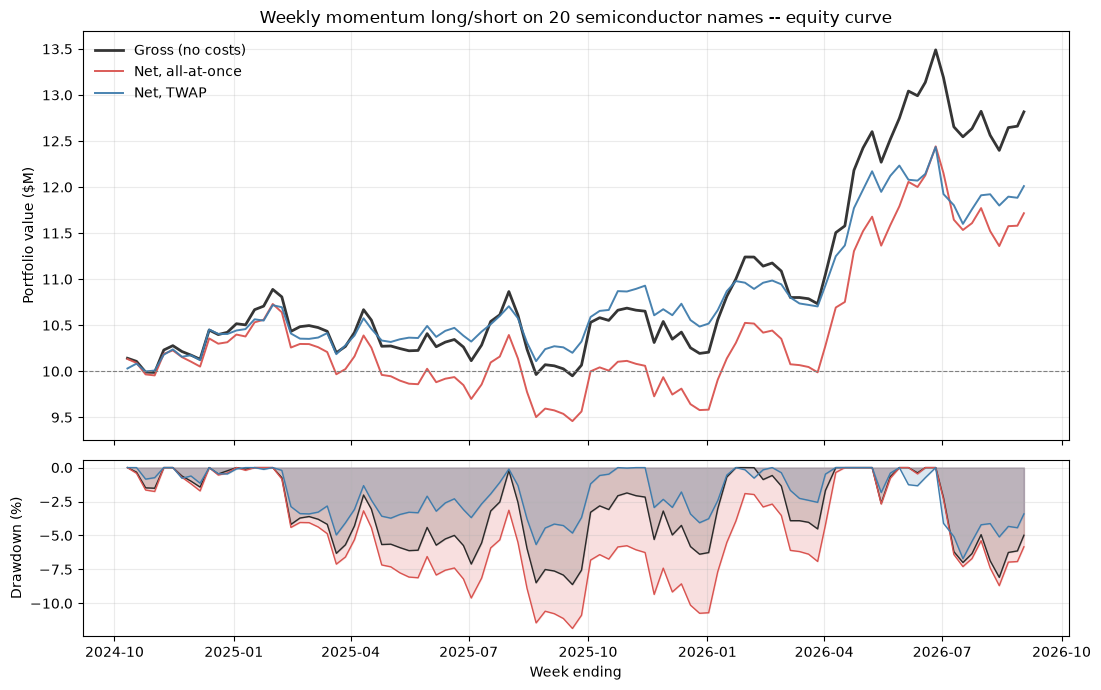

Chart saved to pnl_equity_curve.png


In [9]:
# ============================================================
# 8. CHARTS
# ============================================================
colors = {"gross": "#2a2a2a", "allatonce": "#d9534f", "twap": "#3f7cac"}
labels = {"gross": "Gross (no costs)", "allatonce": "Net, all-at-once", "twap": "Net, TWAP"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.3]})
x = weekly["exit_date"]

for s in STRATEGIES:
    ax1.plot(x, weekly[f"equity_{s}"] / 1e6, label=labels[s], color=colors[s],
             lw=2 if s == "gross" else 1.4, alpha=0.95)
ax1.axhline(CAPITAL_BASE / 1e6, color="grey", lw=0.8, ls="--")
ax1.set_ylabel("Portfolio value ($M)")
ax1.set_title("Weekly momentum long/short on 20 semiconductor names -- equity curve")
ax1.legend(loc="upper left", frameon=False)
ax1.grid(alpha=0.25)

for s in STRATEGIES:
    ax2.fill_between(x, weekly[f"drawdown_{s}"] * 100, 0, color=colors[s], alpha=0.18)
    ax2.plot(x, weekly[f"drawdown_{s}"] * 100, color=colors[s], lw=1)
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Week ending")
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_CHART, dpi=130)
plt.show()
print(f"Chart saved to {OUT_CHART}")


## Step 9 — Sanity checks

Before trusting any of the numbers above, four things must be true:

1. **No missing values** anywhere in the weekly table.
2. **Gross is never worse than net** on any position. Execution cost can only hurt, so
   if a net P&L ever beats gross, a sign is wrong somewhere.
3. **Cost ordering makes sense.** All-at-once should have a lower *impact* cost than
   TWAP (one slice vs. many small ones is the whole point of TWAP). Its *total* cost can
   still be higher or lower depending on how the stock drifted during the week, so we
   only report this, not fail on it.
4. **We agree with Signal.** Signal reported an average weekly long-minus-short spread
   using raw open and close prices. Our gross return should be exactly half of that
   (half the capital is on each side). We recompute Signal's number from the price file
   and compare. A small gap is fine (we round shares down to whole numbers); a large one
   means the two notebooks disagree about which positions exist.


In [10]:
# ============================================================
# 9. SANITY CHECKS
# ============================================================
# 1. No NaNs
nan_cols = weekly.columns[weekly.isna().any()].tolist()
print(f"[{'OK' if not nan_cols else 'FAIL'}] NaNs in weekly table: {nan_cols or 'none'}")

# 2. Gross >= net on every single position -- only true when TWAP has no timing risk,
#    so we enforce it for all-at-once (pure impact) and report it for TWAP.
viol_aao = (positions["pnl_allatonce"] > positions["pnl_gross"] + 1e-6).sum()
print(f"[{'OK' if viol_aao == 0 else 'FAIL'}] Positions where net (all-at-once) beat gross: {viol_aao} "
      f"(must be 0: impact can only hurt)")
viol_twap = (positions["pnl_twap"] > positions["pnl_gross"] + 1e-6).sum()
print(f"[INFO] Positions where net (TWAP) beat gross: {viol_twap} of {len(positions)} "
      f"(allowed: TWAP can get lucky if the stock drifts in our favour during the week)")

# 3. Impact ordering (report only)
avg_cost_aao  = positions["exec_cost_allatonce"].mean()
avg_cost_twap = positions["exec_cost_twap"].mean()
print(f"[INFO] Avg cost per position -- all-at-once ${avg_cost_aao:,.0f} vs TWAP ${avg_cost_twap:,.0f} "
      f"({'TWAP cheaper' if avg_cost_twap < avg_cost_aao else 'all-at-once cheaper'} on average)")

# 4. Agree with signal.ipynb's forward-return spread
wk_first = prices.groupby("week_number")["date"].min()
wk_last  = prices.groupby("week_number")["date"].max()
opens  = prices[prices["date"].isin(set(wk_first))][["week_number", "ticker", "open"]]
closes = prices[prices["date"].isin(set(wk_last))][["week_number", "ticker", "close"]]
fwd = opens.merge(closes, on=["week_number", "ticker"])
fwd["fwd_return"] = fwd["close"] / fwd["open"] - 1
chk = fills[["week_number", "ticker", "side"]].merge(fwd, on=["week_number", "ticker"])
spread = (chk[chk.side == "long"].groupby("week_number")["fwd_return"].mean()
          - chk[chk.side == "short"].groupby("week_number")["fwd_return"].mean())
signal_spread = spread.mean()
ours_x2 = weekly["ret_gross"].mean() * 2
gap_bps = abs(signal_spread - ours_x2) * 10_000
print(f"[{'OK' if gap_bps < 2 else 'FAIL'}] Signal's avg weekly spread {signal_spread:.3%} vs 2 x our gross weekly return "
      f"{ours_x2:.3%} (gap {gap_bps:.2f} bps; small gaps come from rounding shares to whole numbers)")


[OK] NaNs in weekly table: none
[OK] Positions where net (all-at-once) beat gross: 0 (must be 0: impact can only hurt)
[INFO] Positions where net (TWAP) beat gross: 491 of 1000 (allowed: TWAP can get lucky if the stock drifts in our favour during the week)
[INFO] Avg cost per position -- all-at-once $898 vs TWAP $721 (TWAP cheaper on average)
[OK] Signal's avg weekly spread 0.528% vs 2 x our gross weekly return 0.528% (gap 0.02 bps; small gaps come from rounding shares to whole numbers)


## Step 10 — Save the outputs

Three CSVs so later work (a report, a chart notebook, a comparison against live paper-trading
fills) can read the results without rerunning this whole pipeline.


In [11]:
# ============================================================
# 10. SAVE
# ============================================================
pos_cols = ["week_number", "ticker", "side", "direction", "shares", "notional",
            "arrival_price", "fill_allatonce", "fill_twap", "exit_date", "exit_price",
            "pnl_gross", "pnl_allatonce", "pnl_twap", "ret_gross", "ret_allatonce", "ret_twap",
            "exec_cost_allatonce", "exec_cost_twap", "borrow_cost"]
positions_out = positions[pos_cols].copy()
positions_out["exit_date"] = positions_out["exit_date"].dt.strftime("%Y-%m-%d")
positions_out.to_csv(OUT_POSITIONS, index=False)

weekly_out = weekly.copy()
weekly_out["exit_date"] = weekly_out["exit_date"].dt.strftime("%Y-%m-%d")
weekly_out.to_csv(OUT_WEEKLY, index=False)

summary.to_csv(OUT_SUMMARY)

print(f"Saved {len(positions_out):,} rows to {OUT_POSITIONS}")
print(f"Saved {len(weekly_out):,} rows to {OUT_WEEKLY}")
print(f"Saved summary table to {OUT_SUMMARY}")


Saved 1,000 rows to pnl_positions.csv
Saved 100 rows to pnl_weekly.csv
Saved summary table to pnl_summary.csv


## How to read the result

- **Is the annualised return positive after costs?** If not, the signal does not pay for
  its own trading and nothing else matters.
- **Is the Sharpe ratio above about 0.5?** Below that, the result is hard to distinguish
  from noise over a two-year sample. Above 1 would be genuinely interesting.
- **Where did the money come from?** If the longs made it all and the shorts lost, the
  strategy is really "buy strong semis in a bull market", and the short book is just a hedge
  that costs money.
- **How big is execution drag?** With Execution's default impact coefficient of 1.0,
  it comes out around 7-9 bps a week, which is roughly 4-5% a year and a large slice of
  the gross edge. That coefficient is an uncalibrated placeholder (Execution's notebook
  says so), so treat the net numbers as "costs matter a lot" rather than a precise
  estimate. Raise `CAPITAL_BASE` in both notebooks to see how it scales with size.

**Things this backtest does not include**, which would all make real results worse:
commissions, bid/ask spread, borrow fees on the shorts (unless you set them above),
taxes, and the fact that the universe of 20 names was chosen with hindsight.
